# Assignment 2: Linear regression {-}

This assignment aims at familiarizing you with the use of Linear Regression model supported by scikit-learn. You will have to do:

1.  **(5 points) Coding Tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Analyze the dataset using libraries like Pandas and Matplotlib.  
    1.2 *(1 point)* Preprocess the data for modeling.  
    1.3 *(1 point)* Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    1.4 *(1 point)* Train a Linear Regression model on the training set.    
    1.5 *(1 point)* Evaluate the model performance on the test set.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* Does income or income stability have a stronger influence on the loan sanction amount? For example, analyze the data to see if a higher income or a "High" income stability rating leads to a greater loan approval amount.  
    2.2 *(1 point)* Is there a significant difference in loan amounts based on property location? For example, compare the average loan amounts for properties in rural, urban, and semi-urban locations.  
    2.3 *(1 point)* Is there a gender bias in loan approvals? For example, investigate if there is a difference in average loan amounts offered to male and female applicants.  
    2.4 *(1 point)* Are there any new features you could create from the existing data (e.g., loan-to-value ratio) that might be useful for analyzing loan amounts?  
    2.5 *(1 point)* Beyond loan amount prediction, what other insights can be extracted or predicted from this dataset? For example, explore possibilities of using the data to understand borrower behavior, property market trends, or develop targeted marketing strategies.  


The dataset you will be working on is 'house-loan.csv'. It is composed of attributes such as gender, age, income, etc. This dataset is to predict the loan amount for which a customer can request a bank with his/her collateral house.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment2-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DataViz-\<StudentID>-Assignment2 (e.g., DataViz-2012345-Assigment2) and then compressed with the same name.
    
### Evaluation {-}
Assignment evaluation will be conducted on how properly you analyze, pre-process, split the data for training/testing purpose, then build a regression model, evaluate the model performance and reasonably answer the open discussion questions.

Note that the evaluation will not consider the model accuracy as the most important criterion, but how properly you handle the data and build the model to learn the data pattern.

### Deadline {-}
Please visit Canvas for details.


In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

This is a dataset about loan amount for which a customer can request a bank with his/her collateral house.

* Gender: Gender of customer requesting for a loan ('F' or 'M').
* Age: Age of customer requesting for a loan (non-negative values).
* Income (USD): Income of customer requesting for a loan (non-negative values).
* Income Stability: Income stability of customer requesting for a loan ("Low" or "High").
* Property Age: Age of the property (non-negative number of days).
* Property Location: Location of the property ("Rural", "Urban", and "Semi-Urban").
* Property Price: Price of the property (USD).
* Loan Sanction Amount (USD): Amount of loan the customer can request for (USD, target value).

In [132]:
# Load and display data
from google.colab import drive
drive.mount('/content/drive')
loan_data = pd.read_csv('/content/drive/MyDrive/house_loan.csv')
loan_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336


## 1. Coding tasks

In [133]:
# Your code goes here
# 1.1
loan_data.info()
loan_data.shape
loan_data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47297 entries, 0 to 47296
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      47297 non-null  object 
 1   Age                         47297 non-null  int64  
 2   Income (USD)                47265 non-null  float64
 3   Income Stability            47285 non-null  object 
 4   Property Age                47263 non-null  float64
 5   Property Location           47294 non-null  object 
 6   Property Price              47297 non-null  float64
 7   Loan Sanction Amount (USD)  47297 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.9+ MB


,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
count,47297,47297.000000,47265.000000,47285,47263.000000,47294,4.729700e+04,47297.000000
unique,2,NaN,NaN,2,NaN,3,NaN,NaN
top,F,NaN,NaN,Low,NaN,Semi-Urban,NaN,NaN
freq,23669,NaN,NaN,43078,NaN,16371,NaN,NaN
mean,NaN,40.000063,2586.684384,NaN,2586.611058,NaN,1.350880e+05,46487.229765
std,NaN,16.086128,1558.768809,NaN,1558.842286,NaN,9.457875e+04,32549.905634
min,NaN,18.000000,372.700000,NaN,370.700000,NaN,7.859620e+03,254.586578
25%,NaN,24.000000,1653.740000,NaN,1652.820000,NaN,6.250408e+04,21782.822159
50%,NaN,40.000000,2245.480000,NaN,2244.810000,NaN,1.130936e+05,38822.132402
75%,NaN,55.000000,3128.560000,NaN,3128.380000,NaN,1.819546e+05,62612.236905


In [134]:
# Your code goes here
# 1.2
print(loan_data.isnull().sum()) # print out null value datas

Gender                         0
Age                            0
Income (USD)                  32
Income Stability              12
Property Age                  34
Property Location              3
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64


In [135]:
loan_data['Income (USD)'] = loan_data['Income (USD)'].fillna(loan_data['Income (USD)'].mean()) # fill null value with mean value

In [136]:
loan_data.dropna(subset=['Income Stability', 'Property Location'], inplace=True) #remove all the row has null values in 'Income Stability', 'Property Location'

In [137]:
def mean_age_depend_on_location(df, location): # define a function to fill null value in col 'Property Location'
  mean_age = df.loc[df['Property Location'] == location, 'Property Age'].mean() #find mean value in each areas
  return mean_age
location = loan_data['Property Location'].unique()
dictionary = {}
for i in location:
  x = mean_age_depend_on_location(loan_data, i)
  dictionary[i] = x
print(dictionary)

for x, y in dictionary.items():
  loan_data.loc[loan_data['Property Location'] == x, 'Property Age'] = loan_data.loc[loan_data['Property Location'] == x, 'Property Age'].fillna(y)


{'Rural': 2581.6027099930993, 'Urban': 2580.354266506121, 'Semi-Urban': 2596.79232015158}


In [139]:
loan_data.drop_duplicates(inplace=True)

In [140]:
loan_data_copy = loan_data.copy() # make a copy for Open Questions

In [142]:
from sklearn.preprocessing import LabelEncoder # change the catagories data into numerical type
encoder = LabelEncoder()
for column in ['Gender', 'Income Stability', 'Property Location']:
    loan_data[column] = encoder.fit_transform(loan_data[column])

In [143]:
loan_data.head(10)

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,0,19,1641.25,1,1651.25,0,59641.82,21026.420753
1,1,29,1989.71,1,1990.71,2,179858.51,60595.183366
2,0,37,1849.91,1,1856.91,0,117297.62,39181.648002
3,1,65,2735.18,0,2747.18,0,354417.72,128497.710865
4,0,62,4741.78,0,4740.78,2,82049.80,39386.919336
5,0,28,1912.18,1,1919.18,2,28692.18,10055.743846
6,0,59,1586.55,1,1584.55,2,142026.71,45336.365654
7,0,21,6229.34,1,6229.34,1,221243.65,79562.985181
8,0,60,904.26,1,901.26,0,49290.34,13545.640371
9,0,61,1523.72,1,1514.72,2,59790.35,17486.116124


In [147]:
# Your code goes here
# 1.3
columns = loan_data.columns.tolist()
columns.remove('Loan Sanction Amount (USD)')
feature_data = loan_data[columns]
target_data = loan_data['Loan Sanction Amount (USD)']
from sklearn.model_selection import train_test_split
trainX, testX, trainY, testY = train_test_split(feature_data, target_data, train_size = 0.8)
print('Training:' + str(trainX.shape))
print('Training:' + str(trainX.shape))

Training:(37825, 7)
Training:(37825, 7)


In [145]:
# Your code goes here
# 1.4
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(trainX,trainY)
print("Model intercept: " + str(model.named_steps['linearregression'].intercept_))
print("Model coefficients: " + str(model.named_steps['linearregression'].coef_))

Model intercept: 46461.9929245077
Model coefficients: [  -123.29519674  -1281.17617267  28595.72562331  -3177.48669251
 -26988.11452179    -53.9170221   31803.06712784]


In [146]:
# Your code goes here
# 1.5
from sklearn.metrics import mean_absolute_error
pred = model.predict(testX)
mean_absolute_error(y_pred=pred, y_true=testY)

216.11882794596133

## 2. Open discussion questions

In [148]:
# Your argument goes here
# 2.1
coefficients = model.named_steps['linearregression'].coef_
X = loan_data.drop(columns=['Loan Sanction Amount (USD)'])
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)
print(feature_importance)

             Feature   Coefficient
6     Property Price  31803.067128
2       Income (USD)  28595.725623
5  Property Location    -53.917022
0             Gender   -123.295197
1                Age  -1281.176173
3   Income Stability  -3177.486693
4       Property Age -26988.114522


To consider which feature has a greater impact on Loan Sanction Amount:
- We use the model used to train the model here, Linear Regression. The features imported into this model have the same role because their degrees are all of degree 1 (no feature has degree 2 or degree 3, etc.). Therefore, whichever feature has a larger absolute value of the coefficient will have a greater influence.
- In this model, we see that the absolute value of the Income (USD) coefficient is larger than the absolute value of the Income Stability coefficient (approximately 9 times)
- Therefore we can confirm that the feature Income (USD) has greater impact than Income Stability

In [149]:
# Your argument goes here
# 2.2
loan_dictionary_loc = {}
for i in loan_data_copy['Property Location'].unique():
  mean_on_loc = loan_data_copy.loc[loan_data_copy['Property Location'] == i, 'Loan Sanction Amount (USD)'].mean(skipna=True)
  loan_dictionary_loc[i] = mean_on_loc
print(loan_dictionary_loc)

{'Rural': 46637.05610015722, 'Urban': 46496.00709414239, 'Semi-Urban': 46332.97636490589}


There is no significant difference in loan sanction amounts across the three property locations (Rural, Semi-Urban, and Urban), as the average loan amounts are quite similar.

In [151]:
# Your argument goes here
# 2.3
loan_dictionary_gender = {}
for i in loan_data_copy['Gender'].unique():
  mean_on_gender = loan_data_copy.loc[loan_data_copy['Gender'] == i, 'Loan Sanction Amount (USD)'].mean(skipna=True)
  loan_dictionary_gender[i] = mean_on_gender
print(loan_dictionary_gender)

{'F': 46374.65501376327, 'M': 46599.889774168325}


The difference in average loan sanction amounts between males and females is minimal, indicating that there is no significant gender bias in loan approvals.

In [152]:
# Your argument goes here
# 2.4

- Loan-to-gender ratio, the average number of Loan Sanction Amount (USD) per each Genders (Male, Female). This ratio is useful for analyzing spending pattern of each genders.
- Loan-to-Age ratio, the average number of Loan Sanction Amount (USD) per each Age groups (Eg: Teen: 13-18, adults: 18-25,…). This ratio is useful for analyzing Ability of borrowing money.
- Income-to-Loan, calculate the Income(USD) of borower divide for Loan Sanction Amount (USD), it is useful for measures the borrower’s ability to repay the loan
- Property Age-to-Loan ratio, it compares the Age of Property to the Loan Sanction Amount to analyse potential property.

<ipython-input-153-bed900f7cea2>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_by_gender_age = loan_data_copy.groupby(['Gender', 'Age Group'])['Loan Sanction Amount (USD)'].mean().reset_index()


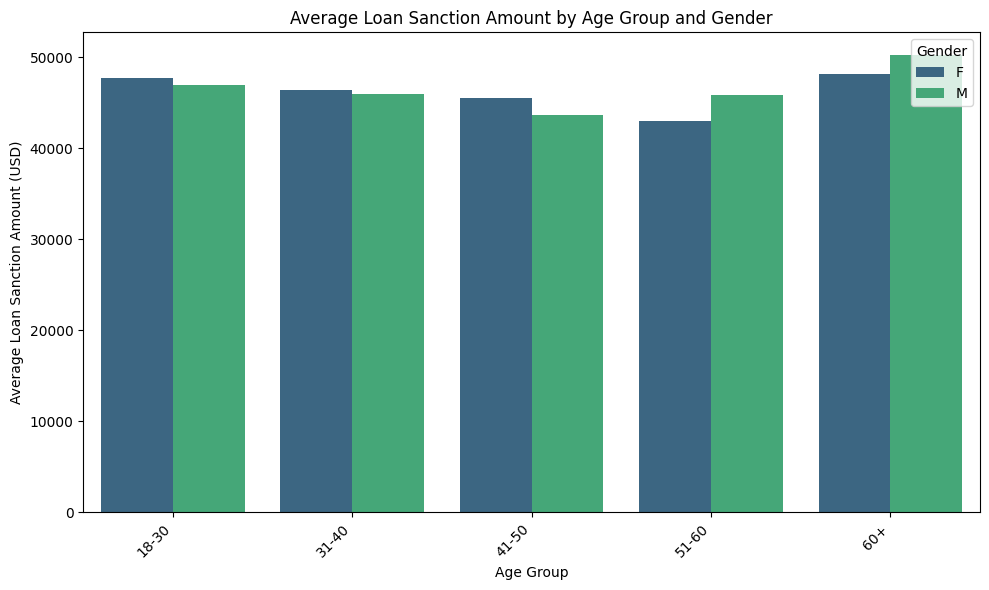

In [153]:
# Your argument goes here
# 2.5
# Average Loan Amount by Gender and Age Groups
import seaborn as sns
import matplotlib.pyplot as plt
loan_data_copy['Age Group'] = pd.cut(loan_data_copy['Age'], bins=[18, 30, 40, 50, 60, 100], labels=["18-30", "31-40", "41-50", "51-60", "60+"], right=False)
loan_by_gender_age = loan_data_copy.groupby(['Gender', 'Age Group'])['Loan Sanction Amount (USD)'].mean().reset_index()
plt.figure(figsize=(10, 6))
age_group_order = ["18-30", "31-40", "41-50", "51-60", "60+"]
sns.barplot(data=loan_by_gender_age, x='Age Group', y='Loan Sanction Amount (USD)', hue='Gender',
            order=age_group_order, palette="viridis")
plt.title("Average Loan Sanction Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Loan Sanction Amount (USD)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

- From this chart we can see a relatively even distribution of Average Loan Sanction Amount among age groups, so it can be said that the tendency to borrow money at all ages is the same. The same thing happens with the Gender section, there is no significant gender bias in loan approvals. ( ex2.3 )

<ipython-input-117-d91d6578d9ae>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_by_income_stability = loan_data_copy.groupby(['Income Stability', 'Income Group'])['Loan Sanction Amount (USD)'].mean().reset_index()


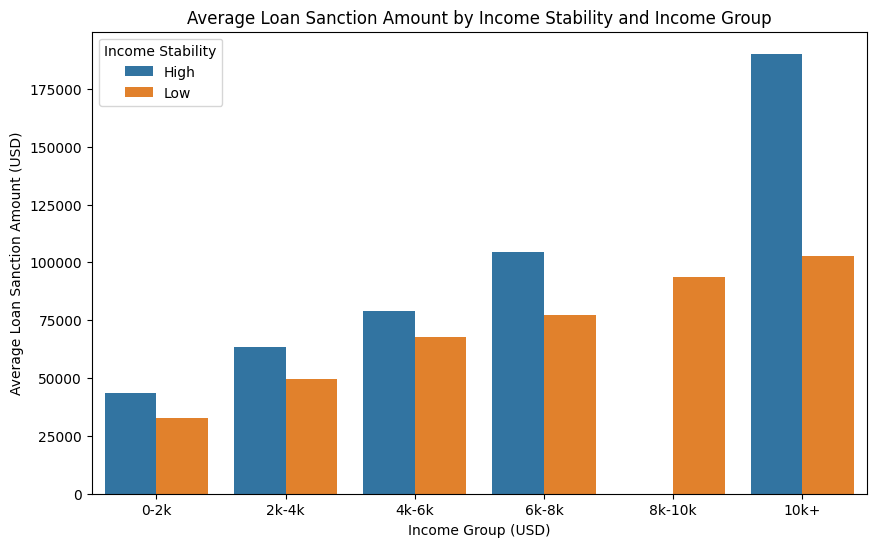

In [ ]:
# Average Loan Amount by Income Stability and Income Groups
loan_data_copy['Income Group'] = pd.cut(loan_data_copy['Income (USD)'], bins=[0, 2000, 4000, 6000, 8000, 10000, 20000],
                                       labels=["0-2k", "2k-4k", "4k-6k", "6k-8k", "8k-10k", "10k+"])

# Calculate the average loan sanction amount by Income Stability and Income Group
loan_by_income_stability = loan_data_copy.groupby(['Income Stability', 'Income Group'])['Loan Sanction Amount (USD)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=loan_by_income_stability, x='Income Group', y='Loan Sanction Amount (USD)', hue='Income Stability')
plt.title("Average Loan Sanction Amount by Income Stability and Income Group")
plt.xlabel("Income Group (USD)")
plt.ylabel("Average Loan Sanction Amount (USD)")
plt.legend(title="Income Stability")
plt.show()

- From this chart it is easy to see a significant difference between Income Groups, a general trend is that the greater the Income, the larger the Loan amount, the group with the highest Average Loan Sanction Amount is 10k+ group, so people with higher income. The bigger they are, the more they tend to borrow more.
- In addition, people with high stable income have a stronger tendency to borrow than people with low stable income, this happens in all income groups. We can see the common habit of people with high stable income is to borrow a lot.

<ipython-input-130-db59d3c382be>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan_by_location_price = loan_data_copy.groupby(['Property Location', 'Property Price Group'])['Loan Sanction Amount (USD)'].mean().reset_index()


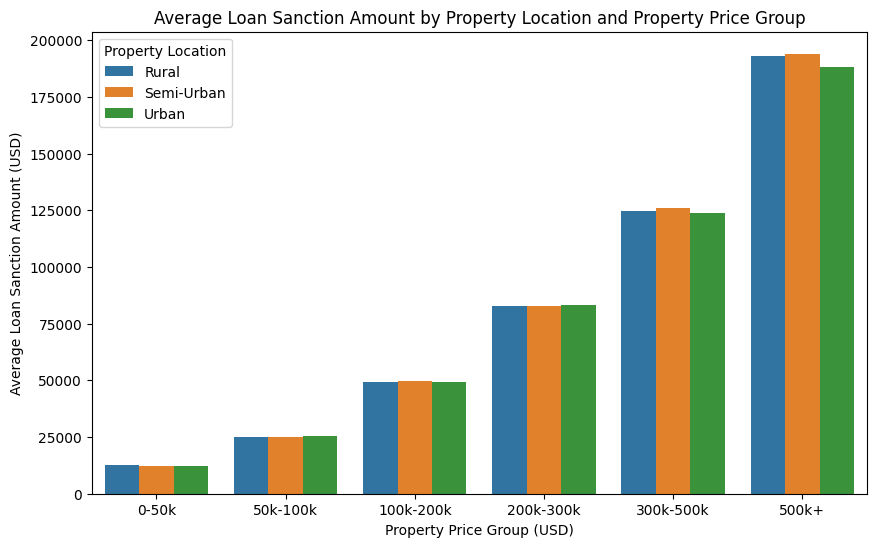

In [ ]:
# Average Loan Amount by Property Location and Price
loan_data_copy['Property Price Group'] = pd.cut(loan_data_copy['Property Price'], bins=[0, 50000, 100000, 200000, 300000, 500000, 1000000],
                                               labels=["0-50k", "50k-100k", "100k-200k", "200k-300k", "300k-500k", "500k+"])

# Calculate the average loan sanction amount by Property Location and Property Price Group
loan_by_location_price = loan_data_copy.groupby(['Property Location', 'Property Price Group'])['Loan Sanction Amount (USD)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=loan_by_location_price, x='Property Price Group', y='Loan Sanction Amount (USD)', hue='Property Location')
plt.title("Average Loan Sanction Amount by Property Location and Property Price Group")
plt.xlabel("Property Price Group (USD)")
plt.ylabel("Average Loan Sanction Amount (USD)")
plt.legend(title="Property Location")
plt.show()

- From exercise 2.2 and this chart, we can easily see the similarity between loan amounts at different Locations.
- A general trend is that the amount of loans on properties increases, the price of that property also increases. Therefore, buyers are willing to borrow a lot to buy high-value properties.

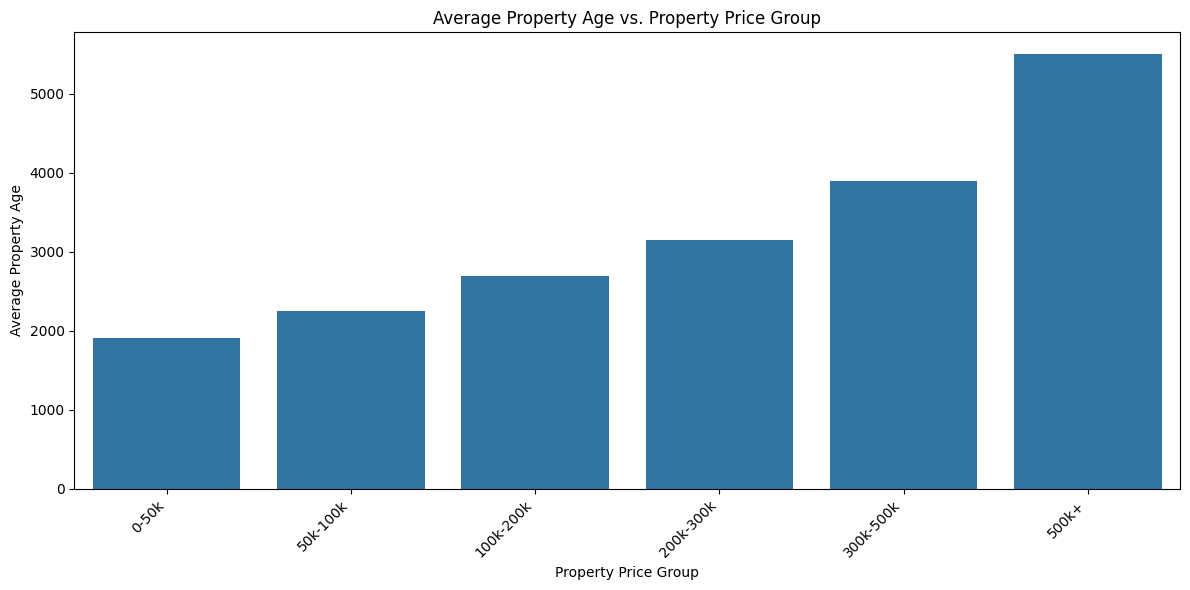

In [ ]:
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x="Property Price Group", y="Property Age", data=loan_data_copy,errorbar=None  )
plt.title("Average Property Age vs. Property Price Group")
plt.xlabel("Property Price Group")
plt.ylabel("Average Property Age")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

- From the chart just analyzed above, we see that properties have high value, users tend to borrow a lot to pay for it. In this chart, we see that the higher the Age of the Property, the higher the value of that Property.

**Marketing strategy**

